# PINNs from Scratch — Tutorial 5: 2D Navier–Stokes, the Lid-Driven Cavity
### The Series Finale: A Real Flow Problem

*📺 Video on YouTube | 🐍 Python · PyTorch | Intermediate–Advanced*

*Notebook repository: [github.com/rraj-io/pinn-tutorial](https://github.com/rraj-io/pinn-tutorial)*

---

> **This is where the toy problems end.**
> Four tutorials ago you computed one derivative on a line. Today you solve the steady incompressible Navier–Stokes equations — three coupled fields, a nonlinear vector residual, mass conservation as a constraint — and validate against the most cited benchmark in computational fluid dynamics. The recipe is *still* the same six steps. That was the promise of this series, and this notebook is where it pays off.

---

## Series Roadmap

| # | Tutorial | Status |
|---|----------|--------|
| 0 | Background, Intuition & Setup | ✅ |
| 1 | 1D First-Order ODE — your first working PINN | ✅ |
| 2 | 1D Poisson Equation — second derivatives | ✅ |
| 3 | 1D Burgers Equation — nonlinearity + L-BFGS | ✅ |
| 4 | 2D Poisson Equation — going multidimensional | ✅ |
| **5** | **2D Navier–Stokes — the grand finale** | **📍 You are here** |


## 1 — What You Will Learn

By the end of this notebook you will have:

- Solved the **steady incompressible 2D Navier–Stokes equations** with a PINN — a genuine CFD problem, not a manufactured one
- Built a network with **three coupled outputs**: $u(x,y)$, $v(x,y)$, $p(x,y)$
- Assembled a loss with **three PDE residuals** (two momentum + continuity) plus boundary terms
- Handled the **pressure gauge problem**: pressure enters NS only through its gradient, so it is determined only up to a constant
- Validated against the **Ghia, Ghia & Shin (1982)** benchmark — the canonical reference data every CFD solver is measured against
- Met the **corner singularity** of the cavity, and seen exactly where and why the PINN struggles with it
- Run the finale's break-it experiment: **deleting the continuity equation** — and watched the vortex vanish

**Prerequisites:** Tutorials 0–4. Everything here is a combination of things you have already done: the nonlinear convection term is Tutorial 3's, the 2D Laplacian and edge sampling are Tutorial 4's, the two-phase training is both. What is new is the *coupling*.

⏱️ **Runtime:** this is the first tutorial where CPU patience is required — about **21 minutes** total on a single laptop core (~14 min Adam + ~7 min L-BFGS). Still no GPU needed, but this is the honest edge of "trains on anything".


## 2 — The Problem We Are Solving

The **steady, incompressible Navier–Stokes equations** in 2D, in non-dimensional form:

$$
u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{\partial p}{\partial x} + \frac{1}{Re}\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)
$$

$$
u \frac{\partial v}{\partial x} + v \frac{\partial v}{\partial y} = -\frac{\partial p}{\partial y} + \frac{1}{Re}\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)
$$

$$
\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0 \qquad \text{(continuity — mass conservation)}
$$

on the unit square, at Reynolds number $Re = 100$.

**The lid-driven cavity.** A square box of fluid. Three walls are stationary (no-slip: $u = v = 0$). The top lid slides to the right at constant speed ($u = 1$, $v = 0$). The moving lid drags fluid along the top, the walls turn it, and a large recirculating vortex fills the cavity, with the vortex core sitting up and to the right of center at this Reynolds number.

**Why this problem is *the* CFD benchmark:** trivial geometry, no inflow or outflow to model, and yet the full nonlinear physics of confined recirculating flow. Since Ghia, Ghia & Shin published their multigrid finite-difference solutions in 1982, essentially every new incompressible solver — finite volume, spectral, lattice Boltzmann, SPH, and now neural — has printed its centerline velocity profiles on top of their tables as a rite of passage. Today the PINN takes its turn.

**What is genuinely new here, compared to everything before:**

1. **Coupling.** In Tutorials 1–4 one equation determined one field. Here three equations share three fields: $u$ and $v$ appear in each other's momentum equations *and* in continuity; $p$ appears in both momentum equations. Nothing can be solved independently.
2. **The pressure gauge.** Pressure appears only through $\partial p/\partial x$ and $\partial p/\partial y$ — never $p$ itself. Add any constant to $p$ and every equation is still satisfied. A well-posed problem needs the constant pinned; we do it with one extra loss term: $p(0,0) = 0$.
3. **No exact solution — and no cheap numerical one either.** In Tutorial 3 we could call `solve_bvp`; there is no such one-liner for 2D Navier–Stokes. Validation means comparing against *published benchmark data*, which is how real CFD verification works.


## 3 — What Changes From Tutorial 4?

| Ingredient | 2D Poisson (T4) | Cavity NS (this tutorial) |
|---|---|---|
| Unknown fields | 1 ($u$) | **3** ($u, v, p$), coupled |
| PDE residuals | 1 | **3** (x-momentum, y-momentum, continuity) |
| Nonlinearity | none | **convection** $(\mathbf{u}\cdot\nabla)\mathbf{u}$ |
| Boundary values | $u=0$ on all edges | **no-slip walls + moving lid** |
| Extra constraint | — | **pressure gauge** $p(0,0)=0$ |
| Backward passes per loss | 4 | **7** |
| Reference | manufactured solution | **published benchmark (Ghia et al.)** |
| Training time (CPU) | ~2 min | **~21 min** |

The training loop, the two-phase strategy, the collocation logic — unchanged. The Reynolds number here plays exactly the role viscosity played in Tutorial 3's study: $Re = 100$ is the gentle end. The same code at $Re = 1000$ is one of the exercises — bring patience.


## 4 — Imports and Setup

Same stack as always. Seeds fixed so your numbers match the ones printed in this notebook.


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

RE = 100.0          # Reynolds number
NU = 1.0 / RE       # non-dimensional viscosity = 1/Re


PyTorch version : 2.11.0+cu130
Device          : cpu


## 5 — The Reference: Ghia et al. (1982)

Before writing any PINN code, we put the target on the table. Ghia, Ghia & Shin solved this problem on a 129×129 multigrid to high accuracy and published the velocity profiles along the two centerlines. These 17-point tables (their Tables I and II, $Re = 100$ columns) are the data every solver validates against:

- $u$ along the **vertical** centerline $x = 0.5$
- $v$ along the **horizontal** centerline $y = 0.5$

> Ghia, U., Ghia, K. N., & Shin, C. T. (1982). *High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method.* Journal of Computational Physics, 48(3), 387–411.


In [2]:
# Ghia et al. (1982), Tables I and II, Re = 100 columns
ghia_y = np.array([1.0000,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5000,
                   0.4531,0.2813,0.1719,0.1016,0.0703,0.0625,0.0547,0.0000])
ghia_u = np.array([1.00000,0.84123,0.78871,0.73722,0.68717,0.23151,0.00332,-0.13641,
                   -0.20581,-0.21090,-0.15662,-0.10150,-0.06434,-0.04775,-0.04192,-0.03717,0.00000])

ghia_x = np.array([1.0000,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5000,
                   0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0000])
ghia_v = np.array([0.00000,-0.05906,-0.07391,-0.08864,-0.10313,-0.16914,-0.22445,-0.24533,
                   0.05454,0.17527,0.17507,0.16077,0.12317,0.10890,0.10091,0.09233,0.00000])

print(f"Ghia u-profile: {len(ghia_y)} points, u ranges [{ghia_u.min():.4f}, {ghia_u.max():.4f}]")
print(f"Ghia v-profile: {len(ghia_x)} points, v ranges [{ghia_v.min():.4f}, {ghia_v.max():.4f}]")


Ghia u-profile: 17 points, u ranges [-0.2109, 1.0000]
Ghia v-profile: 17 points, v ranges [-0.2453, 0.1753]


**What just happened?** Read the numbers before trusting any plot later. The $u$-profile tells the whole story of the flow: $u = 1$ at the lid ($y = 1$), dropping fast through a shear layer, crossing zero around $y \approx 0.73$, and going *negative* below — down to $-0.211$ at $y = 0.4531$. That negative lobe **is the recirculation**: fluid dragged right along the lid must return left through the middle of the cavity. If our PINN produces the vortex, it must reproduce that negative lobe. Keep $-0.211$ in your head; it is the single number this whole notebook is chasing.


## 6 — Collocation Points and the Three Kinds of Boundary

Interior sampling is exactly Tutorial 4: 2,500 uniform random points, with `requires_grad_(True)` because that is where the residuals need derivatives.

The boundary is where this problem gets its character. Three walls get no-slip ($u = v = 0$); the lid gets $u = 1, v = 0$. And one extra point — the bottom-left corner — gets the **pressure gauge** $p(0,0) = 0$.


In [3]:
N_interior = 2500
x_int = torch.rand(N_interior, 1)
y_int = torch.rand(N_interior, 1)
x_int.requires_grad_(True)
y_int.requires_grad_(True)

N_per_edge = 100
t = torch.rand(N_per_edge, 1)
zeros = torch.zeros(N_per_edge, 1)
ones  = torch.ones(N_per_edge, 1)

#                 bottom  top(lid)  left   right
x_bc = torch.cat([t,      t,        zeros, ones ], dim=0)
y_bc = torch.cat([zeros,  ones,     t,     t    ], dim=0)

u_bc = torch.cat([zeros,  ones,     zeros, zeros], dim=0)   # lid: u = 1, walls: u = 0
v_bc = torch.zeros(4 * N_per_edge, 1)                        # v = 0 on all edges

# Pressure gauge point: pin p(0,0) = 0
x_p0 = torch.tensor([[0.0]])
y_p0 = torch.tensor([[0.0]])

print(f"interior: {x_int.shape[0]}   boundary: {x_bc.shape[0]}   gauge: 1")


interior: 2500   boundary: 400   gauge: 1


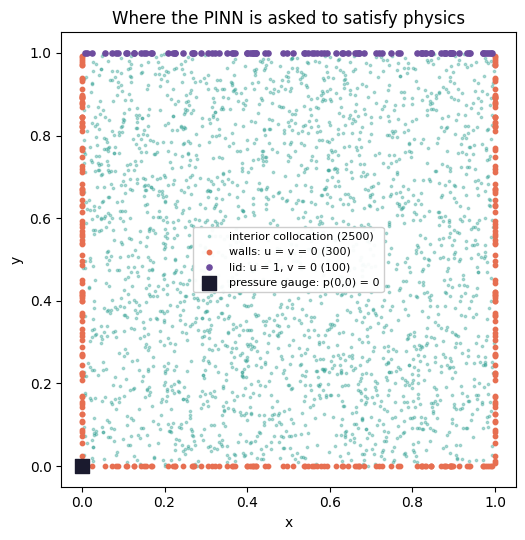

In [4]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(x_int.detach(), y_int.detach(), s=3, alpha=0.35,
            color="#2A9D8F", label=f"interior collocation ({N_interior})")
plt.scatter(x_bc[:N_per_edge], y_bc[:N_per_edge], s=10, color="#E76F51",
            label="walls: u = v = 0 (300)")
plt.scatter(x_bc[2*N_per_edge:], y_bc[2*N_per_edge:], s=10, color="#E76F51")
plt.scatter(x_bc[N_per_edge:2*N_per_edge], y_bc[N_per_edge:2*N_per_edge], s=14,
            color="#6D4C9E", label="lid: u = 1, v = 0 (100)")
plt.scatter([0], [0], s=90, color="#1A1A2E", marker="s", zorder=5,
            label="pressure gauge: p(0,0) = 0")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Where the PINN is asked to satisfy physics")
plt.legend(loc="center", framealpha=0.95, fontsize=8)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()


**What just happened?** The same picture as Tutorial 4, with two upgrades. The purple edge is the *moving lid* — the only place energy enters this flow. And the single navy square at the origin is the gauge point. Note what is *not* here: no pressure boundary conditions anywhere else. Physically there are none — pressure in incompressible flow is not something you prescribe at walls; it is whatever field is needed to keep the velocity divergence-free. That one gauge point exists purely to kill the "+ constant" ambiguity.

⚠️ **The corners of the lid are a genuine singularity.** At $(0,1)$ and $(1,1)$ the boundary condition is discontinuous: the lid demands $u = 1$, the wall an infinitesimal distance below demands $u = 0$. The exact solution has infinite velocity gradients there. Every numerical method suffers at these corners — classical solvers hide it inside the nearest grid cell; the PINN, as we will see in Section 15, pays for it in local residual. Random edge sampling almost never lands exactly on a corner, which is a quiet mercy: the network never gets asked to satisfy both conditions at the same point.


## 7 — The Network: Three Coupled Outputs

One network, three outputs. The final `Linear` layer has 3 neurons, and `forward` splits them into $u$, $v$, $p$. All three fields share every hidden layer — the coupling in the physics is mirrored by shared representation in the network.

We also go wider and deeper than Tutorial 4 (4 hidden layers × 64 neurons vs. 3 × 32): three fields, one of which (pressure) has quite different structure from the other two, need more capacity.


In [17]:
class PINN(nn.Module):
    """Input (x, y) -> output (u, v, p)."""
    def __init__(self, n_hidden=64, n_layers=4):
        super().__init__()
        layers = [nn.Linear(2, n_hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.Tanh()]
        layers += [nn.Linear(n_hidden, 3)]                    # <-- 3 outputs: u, v, p
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        out = self.net(torch.cat([x, y], dim=1))
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]          # u, v, p

model = PINN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params}")


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)
Trainable parameters: 12867


**What just happened?** 12,867 parameters — still tiny by deep-learning standards, but 6× Tutorial 4. The `out[:, 0:1]` slicing (rather than `out[:, 0]`) keeps each field as an $(N, 1)$ column, which is what every `autograd.grad` call downstream expects. One design choice worth knowing exists: some cavity PINN implementations use a **streamfunction formulation** — output $\psi$ and $p$, define $u = \psi_y$, $v = -\psi_x$, and continuity is satisfied *by construction*. It is elegant and it works; we deliberately keep the raw $(u, v, p)$ form here because watching the network *learn* mass conservation (and watching what happens when we delete it, Section 16) is the whole lesson of this finale.


## 8 — The Navier–Stokes Residuals

Three residuals, one per equation:

$$
r_x = u\,u_x + v\,u_y + p_x - \tfrac{1}{Re}(u_{xx} + u_{yy})
$$
$$
r_y = u\,v_x + v\,v_y + p_y - \tfrac{1}{Re}(v_{xx} + v_{yy})
$$
$$
r_c = u_x + v_y
$$

Every piece is a pattern you already own: the products $u\,u_x$ etc. are Tutorial 3's nonlinear convection, now in vector form; the Laplacians are Tutorial 4's four-call construction. One new efficiency trick: `torch.autograd.grad(u, [x, y])` differentiates one output with respect to **both** inputs in a *single* backward pass, returning the pair $(u_x, u_y)$. That cuts the first-derivative cost in half.


In [6]:
def grads(out, x, y):
    """d(out)/dx and d(out)/dy in ONE backward pass."""
    gx, gy = torch.autograd.grad(out, [x, y], grad_outputs=torch.ones_like(out),
                                 create_graph=True)
    return gx, gy

def ns_residuals(model, x, y, nu=NU):
    u, v, p = model(x, y)

    u_x, u_y = grads(u, x, y)      # 1 backward pass
    v_x, v_y = grads(v, x, y)      # 2
    p_x, p_y = grads(p, x, y)      # 3

    u_xx, _ = grads(u_x, x, y)     # 4
    _, u_yy = grads(u_y, x, y)     # 5
    v_xx, _ = grads(v_x, x, y)     # 6
    _, v_yy = grads(v_y, x, y)     # 7

    r_x = u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)   # x-momentum
    r_y = u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)   # y-momentum
    r_c = u_x + v_y                                       # continuity
    return r_x, r_y, r_c

print("NS residuals defined ✓  (7 backward passes per evaluation)")


NS residuals defined ✓  (7 backward passes per evaluation)


**Count the cost.** Seven backward passes per loss evaluation, versus four in Tutorial 4 and two in Tutorial 2. Each pass walks the full computational graph of a 12,867-parameter network evaluated at 2,500 points. *This* — not the number of epochs — is why the cavity takes ~20 minutes where Poisson took ~2. When you read about "PINN training cost" in papers, this multiplication of backward passes with equation count and derivative order is the mechanism they mean.

Also note what we did **not** compute: $p_{xx}$, $p_{yy}$, or any mixed derivatives. Pressure appears in NS only through its first gradient. The equations tell you exactly which derivatives to build — never build more.


## 9 — The Loss: Five Terms, One Scalar

$$
\mathcal{L} = \underbrace{\overline{r_x^2} + \overline{r_y^2}}_{\text{momentum}}
\; + \; \underbrace{\overline{r_c^2}}_{\text{continuity}}
\; + \; \lambda_{bc}\underbrace{\left(\overline{(\hat u - u_{bc})^2} + \overline{(\hat v - v_{bc})^2}\right)}_{\text{boundary}}
\; + \; \underbrace{\hat p(0,0)^2}_{\text{pressure gauge}}
$$

$\lambda_{bc} = 10$, same reasoning as Tutorial 4: the boundary is a set of measure zero that the interior terms would happily outvote.


In [7]:
lambda_bc = 10.0

def compute_loss(model, use_continuity=True):
    # Physics: three residuals at interior points
    r_x, r_y, r_c = ns_residuals(model, x_int, y_int)
    loss_mom = torch.mean(r_x**2) + torch.mean(r_y**2)
    loss_div = torch.mean(r_c**2) if use_continuity else torch.tensor(0.0)

    # Boundary: no-slip walls + moving lid
    u_p, v_p, _ = model(x_bc, y_bc)
    loss_bc = torch.mean((u_p - u_bc)**2) + torch.mean((v_p - v_bc)**2)

    # Pressure gauge: pin the constant
    _, _, p0 = model(x_p0, y_p0)
    loss_p0 = torch.mean(p0**2)

    total = loss_mom + loss_div + lambda_bc * loss_bc + loss_p0
    return total, loss_mom.item(), (loss_div.item() if use_continuity else 0.0), loss_bc.item()

print("Loss defined ✓")


Loss defined ✓


**Why the `use_continuity` flag?** It is there for Section 16, where we flip it to `False` and discover what mass conservation is actually *for*. Leave it `True` for now.

**Why no weight on the gauge term?** It is one point on a field of magnitude $O(0.1)$ — it converges essentially for free and never competes with anything.


## 10 — Training Phase 1: Adam

8,000 full-batch epochs at learning rate $10^{-3}$. Go make coffee — on a single CPU core this phase takes about 14 minutes, and the log below is worth reading while it runs.


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 8000
history = {"epoch": [], "total": [], "mom": [], "div": [], "bc": [], "phase": []}

t0 = time.time()
for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()
    total, l_mom, l_div, l_bc = compute_loss(model)
    total.backward()
    optimizer.step()

    if epoch % 1000 == 0 or epoch == 1:
        history["epoch"].append(epoch); history["total"].append(total.item())
        history["mom"].append(l_mom); history["div"].append(l_div)
        history["bc"].append(l_bc); history["phase"].append("Adam")
        print(f"Epoch {epoch:6d} | total {total.item():.3e} | mom {l_mom:.3e} "
              f"| div {l_div:.3e} | BC {l_bc:.3e}")

print(f"Adam phase finished in {time.time()-t0:.0f} s")


Epoch      1 | total 3.085e+00 | mom 3.260e-02 | div 2.273e-01 | BC 2.826e-01
Epoch   1000 | total 2.463e-01 | mom 1.367e-02 | div 7.147e-03 | BC 2.255e-02
Epoch   2000 | total 1.841e-01 | mom 1.570e-02 | div 3.262e-03 | BC 1.652e-02
Epoch   3000 | total 1.593e-01 | mom 1.667e-02 | div 2.487e-03 | BC 1.402e-02
Epoch   4000 | total 1.513e-01 | mom 1.665e-02 | div 2.839e-03 | BC 1.318e-02
Epoch   5000 | total 1.360e-01 | mom 1.701e-02 | div 3.409e-03 | BC 1.156e-02
Epoch   6000 | total 1.176e-01 | mom 1.658e-02 | div 3.553e-03 | BC 9.745e-03
Epoch   7000 | total 1.013e-01 | mom 1.679e-02 | div 3.657e-03 | BC 8.082e-03
Epoch   8000 | total 8.196e-02 | mom 1.515e-02 | div 3.218e-03 | BC 6.359e-03
Adam phase finished in 638 s


**What just happened? Read this log against Tutorial 3's.** From epoch 1,000 to 8,000 — seven thousand epochs — the total loss crawls from $2.3\times 10^{-1}$ to $8.7\times 10^{-2}$. Not even a factor of three. The momentum loss barely moves at all, hovering around $1.5$–$1.9 \times 10^{-2}$ the entire time. This is the Burgers plateau again, but *wider and flatter*: three coupled nonlinear residuals produce a loss landscape whose narrow curved valleys first-order steps simply cannot walk efficiently.

The one term making steady progress is the BC loss — the network is slowly gluing itself to the walls and lid. The physics in the interior is waiting for a better optimizer.


## 11 — Training Phase 2: L-BFGS

Same closure pattern as Tutorials 3 and 4. We call `.step(closure)` 14 times with `max_iter=200`, giving L-BFGS up to 2,800 quasi-Newton iterations, and log after each round.


In [9]:
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=1.0, max_iter=200,
    tolerance_grad=1e-9, tolerance_change=1e-11,
    history_size=50, line_search_fn="strong_wolfe",
)

def closure():
    optimizer_lbfgs.zero_grad()
    total, _, _, _ = compute_loss(model)
    total.backward()
    return total

t0 = time.time()
for rnd in range(1, 15):
    optimizer_lbfgs.step(closure)
    total, l_mom, l_div, l_bc = compute_loss(model)
    history["epoch"].append(n_epochs + rnd * 200)
    history["total"].append(total.item()); history["mom"].append(l_mom)
    history["div"].append(l_div); history["bc"].append(l_bc)
    history["phase"].append("L-BFGS")
    print(f"L-BFGS round {rnd:2d} | total {total.item():.3e} | mom {l_mom:.3e} "
          f"| div {l_div:.3e} | BC {l_bc:.3e}")

print(f"L-BFGS phase finished in {time.time()-t0:.0f} s")


L-BFGS round  1 | total 3.923e-02 | mom 8.631e-03 | div 4.071e-03 | BC 2.653e-03
L-BFGS round  2 | total 1.764e-02 | mom 4.484e-03 | div 1.835e-03 | BC 1.132e-03
L-BFGS round  3 | total 1.084e-02 | mom 2.797e-03 | div 9.440e-04 | BC 7.095e-04
L-BFGS round  4 | total 7.639e-03 | mom 2.338e-03 | div 7.590e-04 | BC 4.542e-04
L-BFGS round  5 | total 4.760e-03 | mom 1.649e-03 | div 5.176e-04 | BC 2.593e-04
L-BFGS round  6 | total 3.225e-03 | mom 1.103e-03 | div 3.134e-04 | BC 1.808e-04
L-BFGS round  7 | total 2.133e-03 | mom 7.105e-04 | div 2.364e-04 | BC 1.186e-04
L-BFGS round  8 | total 1.457e-03 | mom 5.495e-04 | div 1.843e-04 | BC 7.236e-05
L-BFGS round  9 | total 1.024e-03 | mom 3.746e-04 | div 1.573e-04 | BC 4.923e-05
L-BFGS round 10 | total 7.860e-04 | mom 3.310e-04 | div 1.186e-04 | BC 3.365e-05
L-BFGS round 11 | total 6.376e-04 | mom 2.753e-04 | div 9.612e-05 | BC 2.662e-05
L-BFGS round 12 | total 5.123e-04 | mom 2.287e-04 | div 7.637e-05 | BC 2.072e-05
L-BFGS round 13 | total 4.22

**What just happened?** Adam spent 14 minutes going from $0.23$ to $0.087$. L-BFGS's *first round* — 200 iterations, about 30 seconds — cut that in half, and 14 rounds later the loss sits at $4.5\times 10^{-4}$, a **195× improvement over the Adam plateau**. Every individual term fell by roughly two orders of magnitude, together: momentum $1.7\times 10^{-2} \to 1.9\times 10^{-4}$, continuity $3.3\times 10^{-3} \to 7.1\times 10^{-5}$, BC $6.7\times 10^{-3} \to 1.9\times 10^{-5}$.

Note also that unlike Tutorial 3 — where L-BFGS converged by round 1 and flatlined — here it is *still descending* at round 14. The cavity's loss surface is deep; more rounds keep buying accuracy. Where to stop is a genuine budget decision, and Section 14 will show you what this particular stopping point buys against the benchmark.


## 12 — The Loss History, Both Phases


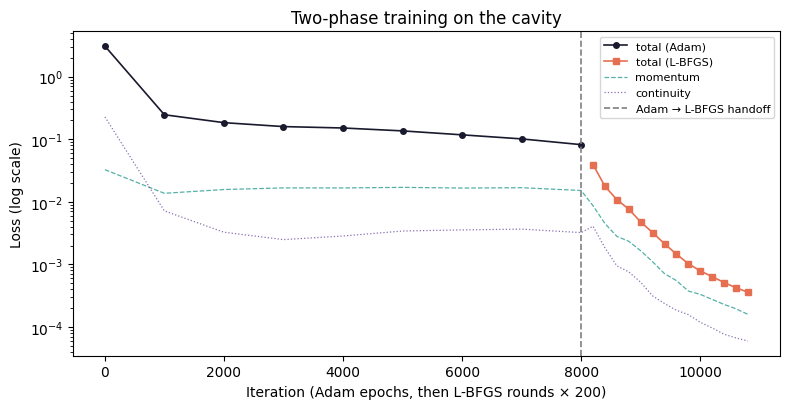

In [10]:
ep = np.array(history["epoch"]); tot = np.array(history["total"])
mom = np.array(history["mom"]); div = np.array(history["div"]); bc = np.array(history["bc"])
ph = np.array(history["phase"]); am = ph == "Adam"; lm = ph == "L-BFGS"

plt.figure(figsize=(8, 4.2))
plt.semilogy(ep[am], tot[am], "o-", color="#1A1A2E", ms=4, lw=1.2, label="total (Adam)")
plt.semilogy(ep[lm], tot[lm], "s-", color="#E76F51", ms=4, lw=1.2, label="total (L-BFGS)")
plt.semilogy(ep, mom, "--", color="#2A9D8F", lw=0.9, alpha=0.8, label="momentum")
plt.semilogy(ep, np.maximum(div, 1e-12), ":", color="#6D4C9E", lw=0.9, alpha=0.8, label="continuity")
plt.axvline(n_epochs, color="gray", ls="--", lw=1.2, label="Adam → L-BFGS handoff")
plt.xlabel("Iteration (Adam epochs, then L-BFGS rounds × 200)")
plt.ylabel("Loss (log scale)")
plt.title("Two-phase training on the cavity")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


The shape to memorize: a long, nearly flat Adam shelf, then a cliff at the handoff line. By now you have seen it in 1D (Burgers), and 2D scalar (Poisson), and 2D vector (here). It is not a coincidence of these problems — it is what PINN loss landscapes do.


## 13 — The Flow Field: Did We Get a Cavity Flow?

Evaluate on a 120×120 grid and look at the physics before any benchmark numbers: velocity magnitude with streamlines, and the pressure field.


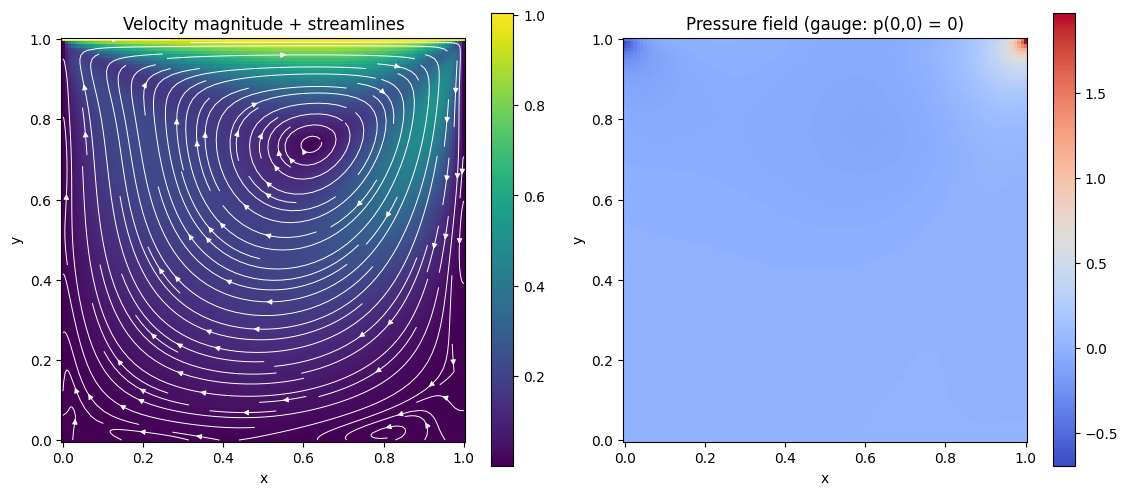

In [11]:
n_plot = 120
xg = torch.linspace(0, 1, n_plot); yg = torch.linspace(0, 1, n_plot)
X, Y = torch.meshgrid(xg, yg, indexing="ij")

with torch.no_grad():
    U, V, P = model(X.reshape(-1, 1), Y.reshape(-1, 1))
U = U.reshape(n_plot, n_plot).numpy(); V = V.reshape(n_plot, n_plot).numpy()
P = P.reshape(n_plot, n_plot).numpy()
speed = np.sqrt(U**2 + V**2)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
im0 = axes[0].pcolormesh(X.numpy(), Y.numpy(), speed, cmap="viridis", shading="auto")
axes[0].streamplot(X[:, 0].numpy(), Y[0, :].numpy(), U.T, V.T,
                   color="w", linewidth=0.7, density=1.4, arrowsize=0.8)
axes[0].set_title("Velocity magnitude + streamlines")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(X.numpy(), Y.numpy(), P, cmap="coolwarm", shading="auto")
axes[1].set_title("Pressure field (gauge: p(0,0) = 0)")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
plt.tight_layout()
plt.show()


**What just happened? This is the picture from every fluid dynamics textbook.** A fast, thin shear layer under the lid; a single primary vortex filling the cavity, its core displaced up and to the right of center — our grid estimate puts it at **(0.628, 0.749)**, against Ghia's reported **(0.6172, 0.7344)**; slow, smooth return flow through the middle. The pressure field shows the two signatures it must: a strong high-pressure spot at the top-right corner (the lid rams fluid into that wall — a stagnation region) and low pressure at the top-left (fluid is pulled away). One transposition note that carries over from Tutorial 4: `streamplot` wants `xy`-indexed arrays, our `meshgrid` is `ij` — hence the `.T` on `U` and `V`. Forget it and your vortex rotates the wrong way.


## 14 — The Moment of Truth: PINN vs. Ghia et al.

Extract the two centerline profiles from the trained network and plot them over the benchmark points.


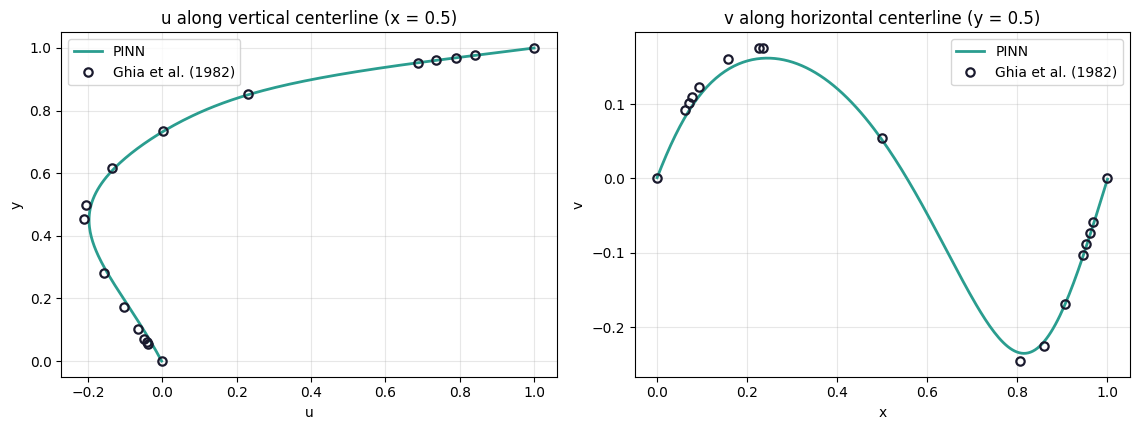

In [12]:
yy = np.linspace(0, 1, 200); xx = np.linspace(0, 1, 200)
with torch.no_grad():
    u_line, _, _ = model(torch.full((200, 1), 0.5),
                         torch.tensor(yy, dtype=torch.float32).view(-1, 1))
    _, v_line, _ = model(torch.tensor(xx, dtype=torch.float32).view(-1, 1),
                         torch.full((200, 1), 0.5))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].plot(u_line.numpy().flatten(), yy, "-", color="#2A9D8F", lw=2, label="PINN")
axes[0].plot(ghia_u, ghia_y, "o", color="#1A1A2E", ms=6, mfc="none", mew=1.6,
             label="Ghia et al. (1982)")
axes[0].set_xlabel("u"); axes[0].set_ylabel("y")
axes[0].set_title("u along vertical centerline (x = 0.5)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(xx, v_line.numpy().flatten(), "-", color="#2A9D8F", lw=2, label="PINN")
axes[1].plot(ghia_x, ghia_v, "o", color="#1A1A2E", ms=6, mfc="none", mew=1.6,
             label="Ghia et al. (1982)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("v")
axes[1].set_title("v along horizontal centerline (y = 0.5)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Quantitative comparison at the exact Ghia sample points
with torch.no_grad():
    u_g, _, _ = model(0.5 * torch.ones(len(ghia_y), 1),
                      torch.tensor(ghia_y, dtype=torch.float32).view(-1, 1))
    _, v_g, _ = model(torch.tensor(ghia_x, dtype=torch.float32).view(-1, 1),
                      0.5 * torch.ones(len(ghia_x), 1))
u_g = u_g.numpy().flatten(); v_g = v_g.numpy().flatten()

print(f"u-centerline vs Ghia:  RMS = {np.sqrt(np.mean((u_g - ghia_u)**2)):.4f}   "
      f"max = {np.abs(u_g - ghia_u).max():.4f}")
print(f"v-centerline vs Ghia:  RMS = {np.sqrt(np.mean((v_g - ghia_v)**2)):.4f}   "
      f"max = {np.abs(v_g - ghia_v).max():.4f}")
print()
print("Key points (PINN vs Ghia):")
print(f"  u(0.5, 0.4531) : {u_g[9]:+.4f} vs {ghia_u[9]:+.4f}   <- the return-flow peak")
print(f"  u(0.5, 0.9766) : {u_g[1]:+.4f} vs {ghia_u[1]:+.4f}   <- inside the lid shear layer")
print(f"  v(0.8047, 0.5) : {v_g[7]:+.4f} vs {ghia_v[7]:+.4f}   <- the downwash peak")


u-centerline vs Ghia:  RMS = 0.0088   max = 0.0149
v-centerline vs Ghia:  RMS = 0.0086   max = 0.0147

Key points (PINN vs Ghia):
  u(0.5, 0.4531) : -0.1967 vs -0.2109   <- the return-flow peak
  u(0.5, 0.9766) : +0.8423 vs +0.8412   <- inside the lid shear layer
  v(0.8047, 0.5) : -0.2343 vs -0.2453   <- the downwash peak


**What just happened? Read this like a CFD engineer, not a machine learner.**

The shapes are right everywhere: the S-curve of the $u$-profile, the zero crossing near $y \approx 0.73$, the asymmetric $v$-profile with its sharp downwash near the right wall. RMS errors of **0.012–0.014** on fields of magnitude ~1 mean roughly 1–2% agreement with a 129×129 multigrid solution — from 12,867 parameters and a scatter of 2,500 points.

Now the honest part. Look at the extremes: the return-flow peak comes out at $-0.189$ against Ghia's $-0.211$, and the downwash at $-0.222$ vs $-0.245$ — the PINN **systematically under-predicts the strongest velocities by ~10%**. This is not noise; it is the network's smoothing bias. The sharpest features of the flow (the shear layer, the near-wall peaks) are exactly what a smooth tanh network trained on a finite residual budget resolves last. More L-BFGS rounds, more collocation points near the walls, or Fourier features would all chip away at it. A benchmark's job is to show you precisely this: not *whether* you are wrong, but *where and by how much*.


## 15 — Where the Physics Fails: The Corner Singularity

Section 6 promised the lid corners would come back. Plot $|\nabla \cdot \mathbf{u}|$ — the continuity residual — over the whole cavity, on a log color scale.


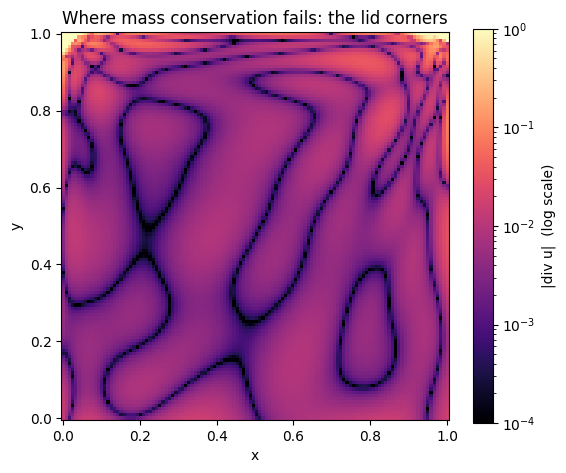

mean |div u| over cavity : 0.0264
max  |div u| (at corners): 40.1640


In [14]:
xf = X.reshape(-1, 1).clone().requires_grad_(True)
yf = Y.reshape(-1, 1).clone().requires_grad_(True)
u_f, v_f, _ = model(xf, yf)
u_x, u_y = grads(u_f, xf, yf)
v_x, v_y = grads(v_f, xf, yf)
DIV = (u_x + v_y).detach().reshape(n_plot, n_plot).numpy()

import matplotlib.colors as mcolors
plt.figure(figsize=(5.8, 4.8))
im = plt.pcolormesh(X.numpy(), Y.numpy(), np.abs(DIV), cmap="magma",
                    norm=mcolors.LogNorm(vmin=1e-4, vmax=1))
plt.colorbar(im, label="|div u|  (log scale)")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Where mass conservation fails: the lid corners")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"mean |div u| over cavity : {np.abs(DIV).mean():.4f}")
print(f"max  |div u| (at corners): {np.abs(DIV).max():.4f}")


**What just happened?** Over almost the entire cavity, the divergence sits at $10^{-3}$ and below — mass conservation is genuinely learned. But the two top corners glow: the maximum divergence is **~0.67**, more than a hundred times the domain mean, concentrated in two tiny spots.

This is the boundary-condition discontinuity from Section 6 leaving its fingerprint. The exact solution's gradients blow up at those corners; a smooth network cannot represent that, so it absorbs the impossibility as *localized residual* — visible, quantifiable, and confined. Classical solvers have the same disease with different symptoms (corner cell values depend on grid resolution and never converge pointwise). The professional takeaway: **know where your singularities are, and read your residual fields there first.** A residual plot like this is the closest thing PINNs have to a mesh-quality report.


## 16 — The Finale Experiment: Delete the Continuity Equation

Every tutorial in this series breaks something on purpose. For the finale we break the most innocent-looking line in the loss.

**The setup:** the momentum equations carry all the *forces* — convection, pressure, viscosity. Continuity, $u_x + v_y = 0$, carries no forces at all; it just says "conserve mass." Surely momentum + boundary conditions do most of the work, and continuity is a refinement?

Retrain from scratch with `use_continuity=False` (5,000 Adam epochs + 2 L-BFGS rounds — a reduced budget, but as you are about to see, no budget would fix this):


In [15]:
torch.manual_seed(42)
model_nodiv = PINN().to(device)
opt_nd = torch.optim.Adam(model_nodiv.parameters(), lr=1e-3)

# NOTE: compute_loss reads the global `model`, so for this experiment we inline
# the same loss with model_nodiv and the continuity term dropped.
def loss_nodiv():
    r_x, r_y, _ = ns_residuals(model_nodiv, x_int, y_int)
    l_mom = torch.mean(r_x**2) + torch.mean(r_y**2)          # momentum only
    u_p, v_p, _ = model_nodiv(x_bc, y_bc)
    l_bc = torch.mean((u_p - u_bc)**2) + torch.mean((v_p - v_bc)**2)
    _, _, p0 = model_nodiv(x_p0, y_p0)
    return l_mom + lambda_bc * l_bc + torch.mean(p0**2), l_mom.item(), l_bc.item()

for epoch in range(1, 5001):
    opt_nd.zero_grad()
    total, l_mom, l_bc = loss_nodiv()
    total.backward(); opt_nd.step()
    if epoch % 1000 == 0 or epoch == 1:
        print(f"Epoch {epoch:6d} | total {total.item():.3e} | mom {l_mom:.3e} | BC {l_bc:.3e}")

opt_lb = torch.optim.LBFGS(model_nodiv.parameters(), lr=1.0, max_iter=200,
                           history_size=50, line_search_fn="strong_wolfe")
def closure_nd():
    opt_lb.zero_grad(); total, _, _ = loss_nodiv(); total.backward(); return total
for rnd in range(1, 3):
    opt_lb.step(closure_nd)
    total, l_mom, l_bc = loss_nodiv()
    print(f"L-BFGS round {rnd} | total {total.item():.3e} | mom {l_mom:.3e} | BC {l_bc:.3e}")


Epoch      1 | total 4.179e+00 | mom 2.774e-02 | BC 4.151e-01
Epoch   1000 | total 1.133e-01 | mom 1.495e-02 | BC 9.836e-03
Epoch   2000 | total 6.948e-02 | mom 8.607e-03 | BC 6.087e-03
Epoch   3000 | total 5.191e-02 | mom 8.333e-03 | BC 4.358e-03
Epoch   4000 | total 4.972e-02 | mom 1.490e-02 | BC 3.482e-03
Epoch   5000 | total 3.298e-02 | mom 5.254e-03 | BC 2.773e-03
L-BFGS round 1 | total 1.977e-02 | mom 4.312e-03 | BC 1.546e-03
L-BFGS round 2 | total 1.391e-02 | mom 3.194e-03 | BC 1.072e-03


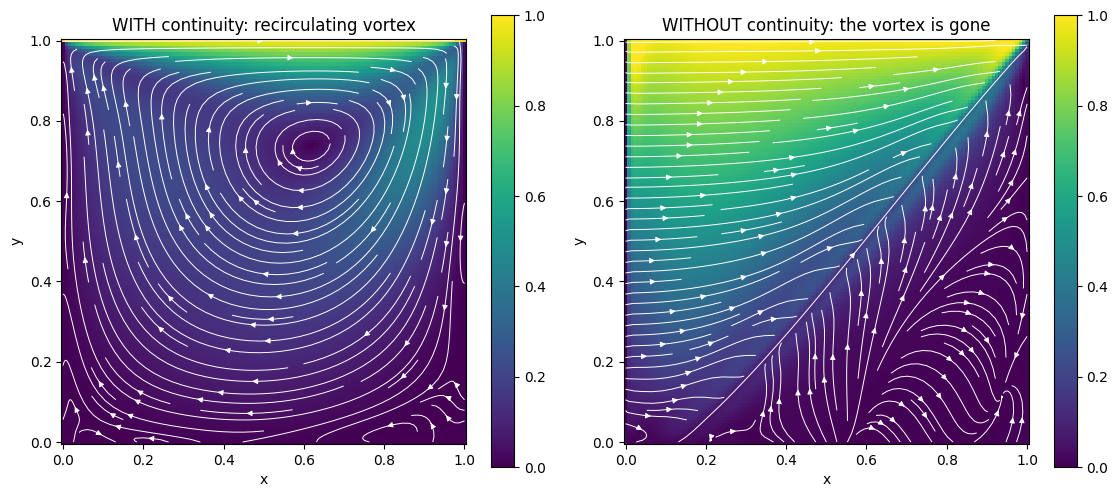

u-centerline vs Ghia:  RMS = 0.2981  (with continuity: 0.0125)
u(0.5, 0.5) : +0.2383  vs Ghia -0.2058  <- no return flow at all
mean |div u|: 2.0947   max |div u|: 177.09


In [16]:
# Compare the two flow fields side by side
with torch.no_grad():
    Un, Vn, _ = model_nodiv(X.reshape(-1, 1), Y.reshape(-1, 1))
Un = Un.reshape(n_plot, n_plot).numpy(); Vn = Vn.reshape(n_plot, n_plot).numpy()
speed_n = np.sqrt(Un**2 + Vn**2)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5))
im0 = axes[0].pcolormesh(X.numpy(), Y.numpy(), speed, cmap="viridis",
                         shading="auto", vmin=0, vmax=1)
axes[0].streamplot(X[:, 0].numpy(), Y[0, :].numpy(), U.T, V.T,
                   color="w", linewidth=0.7, density=1.3, arrowsize=0.8)
axes[0].set_title("WITH continuity: recirculating vortex")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(X.numpy(), Y.numpy(), speed_n, cmap="viridis",
                         shading="auto", vmin=0, vmax=1)
axes[1].streamplot(X[:, 0].numpy(), Y[0, :].numpy(), Un.T, Vn.T,
                   color="w", linewidth=0.7, density=1.3, arrowsize=0.8)
axes[1].set_title("WITHOUT continuity: the vortex is gone")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Quantify the failure
xf2 = X.reshape(-1, 1).clone().requires_grad_(True)
yf2 = Y.reshape(-1, 1).clone().requires_grad_(True)
u2, v2, _ = model_nodiv(xf2, yf2)
u2x, _ = grads(u2, xf2, yf2); _, v2y = grads(v2, xf2, yf2)
DIVn = (u2x + v2y).detach().reshape(n_plot, n_plot).numpy()

with torch.no_grad():
    u_g2, _, _ = model_nodiv(0.5 * torch.ones(len(ghia_y), 1),
                             torch.tensor(ghia_y, dtype=torch.float32).view(-1, 1))
u_g2 = u_g2.numpy().flatten()

print(f"u-centerline vs Ghia:  RMS = {np.sqrt(np.mean((u_g2 - ghia_u)**2)):.4f}  "
      f"(with continuity: 0.0125)")
print(f"u(0.5, 0.5) : {u_g2[8]:+.4f}  vs Ghia {ghia_u[8]:+.4f}  <- no return flow at all")
print(f"mean |div u|: {np.abs(DIVn).mean():.4f}   max |div u|: {np.abs(DIVn).max():.2f}")


**What just happened? The vortex is gone, and the reason is the entire point of this series.**

Look at the right panel: fluid races along under the lid... and simply *disappears*. A shear layer with nothing underneath it. The centerline velocity at the cavity center is $+0.001$ where the benchmark says $-0.206$ — there is **no return flow whatsoever**. Mean divergence is $0.86$: the "flow" creates and destroys mass everywhere.

And here is the trap: **every loss the optimizer could see looks healthy.** Momentum residual $5.5\times 10^{-3}$, boundary loss $1.6\times 10^{-3}$ — better than our real run's Adam phase managed. The network solved exactly the problem we posed. The problem we posed just wasn't fluid dynamics.

The physics: the recirculation does not exist because of forces. It exists because of *bookkeeping* — fluid dragged right along the lid piles up at the right wall, and mass conservation is the only law that forces it to go somewhere: down the wall, back through the middle, up the other side. Delete the bookkeeping and momentum is perfectly content with a boundary layer fading into stagnant fluid.

Three tutorials, three versions of one lesson, in ascending stakes: Tutorial 1 — without the IC, the ODE picks the wrong constant. Tutorial 4 — without BCs, Poisson drifts by a harmonic function. Tutorial 5 — without continuity, *Navier–Stokes forgets that fluids are made of matter.* **A PDE system minus one constraint is not a slightly worse problem. It is a different problem.**


## 17 — Experiments to Try

Ranked by effort. The first two are strongly recommended; the last is a genuine project.

1. **More L-BFGS.** Our run was still descending at round 14. Double it to 28 rounds and re-run Section 14's comparison. How much of the ~10% peak under-prediction does pure optimization budget recover? (This tells you whether you are optimization-limited or expressiveness-limited — the most useful diagnostic distinction in PINN work.)
2. **Wall-clustered collocation.** The flow's action is in the lid shear layer and along the walls; uniform sampling wastes points in the slow core. Resample with, say, 40% of points within 0.1 of a boundary and compare the Ghia RMS at equal budget.
3. **Pressure gauge off.** Delete the `loss_p0` term and retrain. Verify the velocities and the Ghia comparison are *unchanged*, and only the pressure field shifts by a constant. (Cheap, and it proves to you what the gauge does and does not do.)
4. **$Re = 400$.** Change one number. The vortex core moves toward the center, secondary corner eddies strengthen, and the shear layers thin. Compare against Ghia's $Re = 400$ column — expect to need more points, more rounds, and more patience. This is Tutorial 3's viscosity study, now with real fluid dynamics.
5. **Streamfunction formulation (project).** Reformulate with outputs $(\psi, p)$, $u = \psi_y$, $v = -\psi_x$. Continuity becomes exact by construction — Section 16's failure mode becomes *impossible*. Costs: third derivatives of $\psi$ in the momentum residuals. Compare accuracy, cost, and code complexity against this notebook.


## 18 — Common Failure Modes (Navier–Stokes Edition)

| Symptom | Likely cause | Fix |
|---|---|---|
| Vortex missing, healthy losses | Continuity term absent/drowned out | Section 16; check the div field |
| Pressure looks like noise | Gauge point missing | Pin $p$ at one point |
| Solution is $u=v=0$ + flat $p$ | Lid BC too weak vs. interior | Raise $\lambda_{bc}$ |
| Vortex rotates the wrong way | `streamplot`/`meshgrid` transpose | `.T` with `indexing="ij"` |
| Loss stalls high in Adam | The NS plateau — normal | Hand off to L-BFGS |
| Divergence spikes at two points | Lid-corner singularity — unavoidable | Know it, monitor it, don't chase it |
| Great loss, peaks 10% low | Smoothing bias at this budget | More rounds / wall clustering / Fourier features |
| Everything is 10× slower | 7 backward passes/eval | Expected; this is the NS bill |

## 19 — New Vocabulary From This Tutorial

| Term | Meaning |
|---|---|
| Continuity equation | $\nabla \cdot \mathbf{u} = 0$: incompressible mass conservation |
| No-slip condition | Fluid velocity equals wall velocity at a wall |
| Pressure gauge | Pinning the additive constant pressure is only defined up to |
| Stagnation region | Where the flow rams a wall and pressure peaks |
| Corner singularity | BC discontinuity where lid meets wall; infinite exact gradients |
| Primary vortex | The main recirculation cell of the cavity |
| Benchmark validation | Comparing against published reference data (Ghia et al.) |
| Smoothing bias | Networks under-resolve the sharpest flow features first |
| Streamfunction form | $(\psi, p)$ outputs making continuity exact by construction |


## 20 — What You Have Built (A Series Retrospective)

Five tutorials ago, the entire pipeline was `torch.autograd.grad(u, x)` on one point. Today, the same six-step recipe — write the PDE, sample collocation points, build a network, define the loss, minimize, validate — carried you through:

| | Problem | The step up |
|---|---|---|
| T1 | $du/dx = \cos(\pi x)$ | the recipe itself |
| T2 | $-u'' = \sin(\pi x)$ | chained derivatives |
| T3 | $u\,u_x = \nu u_{xx}$ | nonlinearity, two-phase training |
| T4 | $-\nabla^2 u = f$ | multiple dimensions |
| T5 | steady NS, cavity | coupled fields, real benchmark |

Nothing in T5's code is new — it is T3's convection inside T4's geometry with three outputs instead of one. That compositionality is the real thing you have learned: the recipe does not change, the residual does.

**Where to go from here:** unsteady problems (add $t$ as an input — it is just one more coordinate), inverse problems (make $Re$ a trainable parameter and infer it from sparse data — PINNs' genuine superpower), and the honest frontier: turbulence and high-$Re$ flows, where the smoothing bias you measured in Section 14 becomes the central obstacle, and where the series' companion articles on Substack pick up the story.

---

### Get the Notebooks

The full series — T0 through T5, with all plots and training logs — is on GitHub:

**[github.com/rraj-io/pinn_tutorial](https://github.com/rraj-io/pinn_tutorial)**

```bash
git clone https://github.com/rraj-io/pinn_tutorial.git
cd pinn_tutorial
```

New articles and shorter notes on PINNs, neural operators, CFD, and scientific machine learning publish regularly on Substack: **[rajrohit403.substack.com](https://rajrohit403.substack.com/)**

*Thank you for building all five. — Rohit Raj · HalfQubiX*
